<a href="https://colab.research.google.com/github/Adichede9085/EDA-DA-21BDS0088/blob/main/21BDS0088.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase-1**

In [1]:
#Name: Aditya Chede
#Registration No: 21BDS0088
#Dataset: Liver Data (https://raw.githubusercontent.com/Adichede9085/EDA-DA-21BDS0088/main/Liver%20Data.csv)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Link to the raw content of the GitHub file
url = "https://raw.githubusercontent.com/Adichede9085/EDA-DA-21BDS0088/main/Liver%20Data.csv"

# Load the CSV data into a DataFrame
ac_data = pd.read_csv(url)

# Display the first few rows of the data
print(ac_data.head())

   Age of the patient Gender of the patient  Total Bilirubin  \
0                65.0                Female              0.7   
1                62.0                  Male             10.9   
2                62.0                  Male              7.3   
3                58.0                  Male              1.0   
4                72.0                  Male              3.9   

   Direct Bilirubin   Alkphos Alkaline Phosphotase  \
0               0.1                          187.0   
1               5.5                          699.0   
2               4.1                          490.0   
3               0.4                          182.0   
4               2.0                          195.0   

    Sgpt Alamine Aminotransferase  Sgot Aspartate Aminotransferase  \
0                            16.0                             18.0   
1                            64.0                            100.0   
2                            60.0                             68.0   
3         

In [2]:
# Dimensions
print(f"Number of rows: {ac_data.shape[0]}")
print(f"Number of columns: {ac_data.shape[1]}")

Number of rows: 30691
Number of columns: 11


In [3]:
# Data types and missing values
print("\nData Info:")
print(ac_data.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4    Alkphos Alkaline Phosphotase         29895 non-null  float64
 5    Sgpt Alamine Aminotransferase        30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8    ALB Albumin                          30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: 

In [4]:
# The result column should be categorical as it has only two values - either 1 or 2.
ac_data.iloc[:, -1] = ac_data.iloc[:, -1].astype('category')
print(ac_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Age of the patient                    30689 non-null  float64 
 1   Gender of the patient                 29789 non-null  object  
 2   Total Bilirubin                       30043 non-null  float64 
 3   Direct Bilirubin                      30130 non-null  float64 
 4    Alkphos Alkaline Phosphotase         29895 non-null  float64 
 5    Sgpt Alamine Aminotransferase        30153 non-null  float64 
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64 
 7   Total Protiens                        30228 non-null  float64 
 8    ALB Albumin                          30197 non-null  float64 
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64 
 10  Result                                30691 non-null  category
dtypes:

<ipython-input-4-28c14e2c3c9e>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        1
1        1
2        1
3        1
4        1
        ..
30686    1
30687    1
30688    1
30689    1
30690    1
Name: Result, Length: 30691, dtype: category
Categories (2, int64): [1, 2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ac_data.iloc[:, -1] = ac_data.iloc[:, -1].astype('category')


In [5]:
# Check for missing values
print("\nMissing Values:")
print(ac_data.isnull().sum())


Missing Values:
Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64


In [6]:
# Proportion of missing values
prop_missing = ac_data.isna().sum() / len(ac_data)
print("Proportion of missing values in dataset:\n", prop_missing)

Proportion of missing values in dataset:
 Age of the patient                      0.000065
Gender of the patient                   0.029390
Total Bilirubin                         0.021114
Direct Bilirubin                        0.018279
 Alkphos Alkaline Phosphotase           0.025936
 Sgpt Alamine Aminotransferase          0.017530
Sgot Aspartate Aminotransferase         0.015053
Total Protiens                          0.015086
 ALB Albumin                            0.016096
A/G Ratio Albumin and Globulin Ratio    0.018214
Result                                  0.000000
dtype: float64


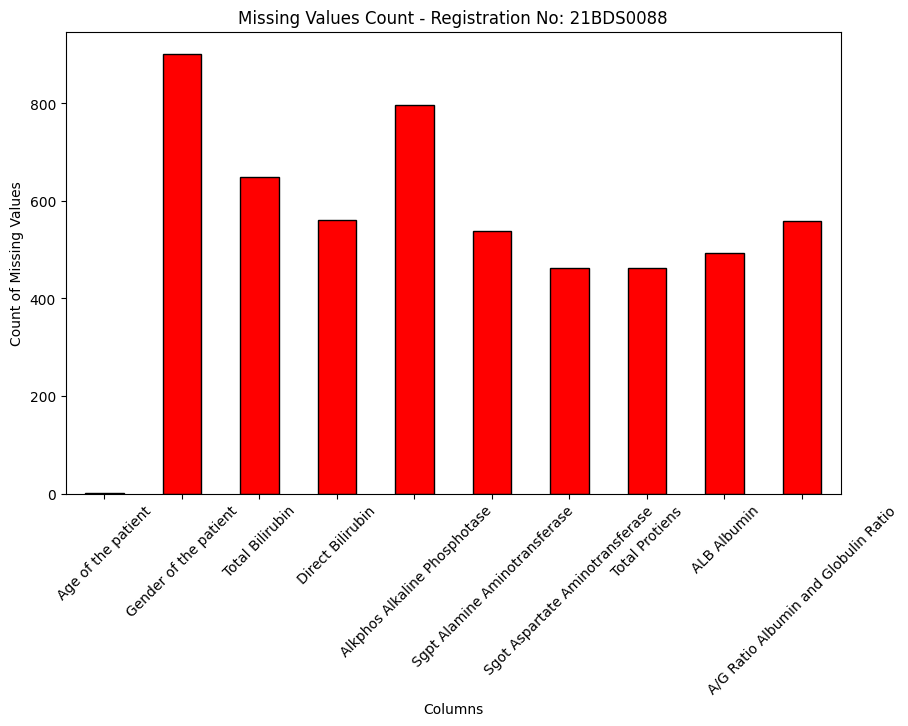

In [7]:
# Missing values visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ac_data.isnull().sum()[ac_data.isnull().sum() > 0].plot(kind='bar', color='red', edgecolor='black')
plt.title("Missing Values Count - Registration No: 21BDS0088")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [8]:
def impute_missing_values(data):
    # Separating numerical and character columns
    numerical_cols = ac_data.select_dtypes(include=['float64', 'int64']).columns
    character_cols = ac_data.select_dtypes(include=['object']).columns

    # Imputing missing values
    ac_data[numerical_cols] = ac_data[numerical_cols].apply(lambda x: x.fillna(x.mean()))  # Mean imputation for numerical columns
    ac_data[character_cols] = ac_data[character_cols].apply(lambda x: x.fillna(x.mode()[0]))  # Mode imputation for categorical columns

    return ac_data

# Applying imputation
data_cleaned = impute_missing_values(ac_data)

# Verifying no missing values remain
print("Missing Values After Imputation:")
print(data_cleaned.isnull().sum())

Missing Values After Imputation:
Age of the patient                      0
Gender of the patient                   0
Total Bilirubin                         0
Direct Bilirubin                        0
 Alkphos Alkaline Phosphotase           0
 Sgpt Alamine Aminotransferase          0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
 ALB Albumin                            0
A/G Ratio Albumin and Globulin Ratio    0
Result                                  0
dtype: int64


In [9]:
# Summary statistics
print("\nSummary Statistics:")
print(data_cleaned.describe())


Summary Statistics:
       Age of the patient  Total Bilirubin  Direct Bilirubin  \
count        30691.000000     30691.000000      30691.000000   
mean            44.107205         3.370319          1.528042   
std             15.980523         6.189129          2.843243   
min              4.000000         0.400000          0.100000   
25%             32.000000         0.800000          0.200000   
50%             45.000000         1.000000          0.300000   
75%             55.000000         2.800000          1.400000   
max             90.000000        75.000000         19.700000   

        Alkphos Alkaline Phosphotase   Sgpt Alamine Aminotransferase  \
count                   30691.000000                    30691.000000   
mean                      289.075364                       81.488641   
std                       235.423816                      180.555155   
min                        63.000000                       10.000000   
25%                       176.000000      

# **Phase-2**

In [10]:
# Computing measures of central tendency (Mean, Median, Mode) for numerical columns.
categorical_cols = ['Gender of the patient', 'Result']
numeric_cols = ac_data.columns.difference(categorical_cols)
for col in numeric_cols:
    print(f"\n{col} - Mean: {ac_data[col].mean()}, Median: {ac_data[col].median()}, Mode: {ac_data[col].mode()[0]}")



A/G Ratio Albumin and Globulin Ratio - Mean: 0.9434674100623922, Median: 0.9434674100623922, Mode: 1.0

Age of the patient - Mean: 44.10720453582717, Median: 45.0, Mode: 45.0

Direct Bilirubin - Mean: 1.528041818785264, Median: 0.3, Mode: 0.2

Sgot Aspartate Aminotransferase - Mean: 111.46997915908565, Median: 43.0, Mode: 23.0

Total Bilirubin - Mean: 3.3703192091335747, Median: 1.0, Mode: 0.8

Total Protiens - Mean: 6.480236866481408, Median: 6.5, Mode: 7.0

 ALB Albumin - Mean: 3.1301420670927578, Median: 3.1, Mode: 3.0

 Alkphos Alkaline Phosphotase - Mean: 289.0753637732062, Median: 214.0, Mode: 289.0753637732062

 Sgpt Alamine Aminotransferase - Mean: 81.48864126289257, Median: 36.0, Mode: 25.0


In [11]:
#Compute measures of dispersion (Standard Deviation, Variance) for numerical columns.
for col in numeric_cols:
    print(f"\n{col} - Std Dev: {ac_data[col].std()}, Variance: {ac_data[col].var()}")



A/G Ratio Albumin and Globulin Ratio - Std Dev: 0.32020726450991543, Variance: 0.10253269224492294

Age of the patient - Std Dev: 15.98052261960619, Variance: 255.37710319574504

Direct Bilirubin - Std Dev: 2.8432434213512976, Variance: 8.084033153057433

Sgot Aspartate Aminotransferase - Std Dev: 278.7291293237891, Variance: 77689.92753359754

Total Bilirubin - Std Dev: 6.1891294238405985, Variance: 38.30532302504946

Total Protiens - Std Dev: 1.0737878357456985, Variance: 1.153020316195431

 ALB Albumin - Std Dev: 0.7858790540552768, Variance: 0.6176058876028166

 Alkphos Alkaline Phosphotase - Std Dev: 235.4238163832973, Variance: 55424.37332047648

 Sgpt Alamine Aminotransferase - Std Dev: 180.5551552968072, Variance: 32600.164104254163


In [12]:
#Compute quartiles and IQR for numerical columns.
for col in numeric_cols:
    Q1 = ac_data[col].quantile(0.25)
    Q3 = ac_data[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"\n{col} - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")



A/G Ratio Albumin and Globulin Ratio - Q1: 0.7, Q3: 1.1, IQR: 0.40000000000000013

Age of the patient - Q1: 32.0, Q3: 55.0, IQR: 23.0

Direct Bilirubin - Q1: 0.2, Q3: 1.4, IQR: 1.2

Sgot Aspartate Aminotransferase - Q1: 26.0, Q3: 90.0, IQR: 64.0

Total Bilirubin - Q1: 0.8, Q3: 2.8, IQR: 1.9999999999999998

Total Protiens - Q1: 5.8, Q3: 7.2, IQR: 1.4000000000000004

 ALB Albumin - Q1: 2.6, Q3: 3.7, IQR: 1.1

 Alkphos Alkaline Phosphotase - Q1: 176.0, Q3: 293.0, IQR: 117.0

 Sgpt Alamine Aminotransferase - Q1: 23.0, Q3: 64.0, IQR: 41.0


# **Univariate Analysis**

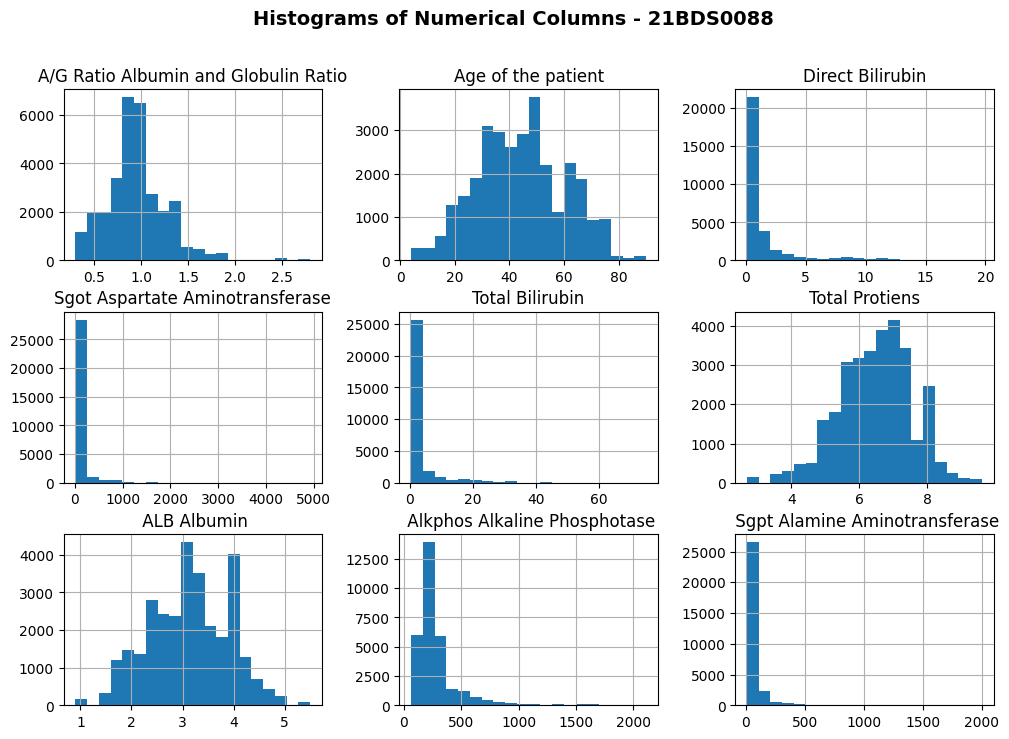

In [13]:
#Plot histograms for all numerical columns.
ac_data[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Histograms of Numerical Columns - 21BDS0088", fontsize=14, fontweight='bold')
plt.show()

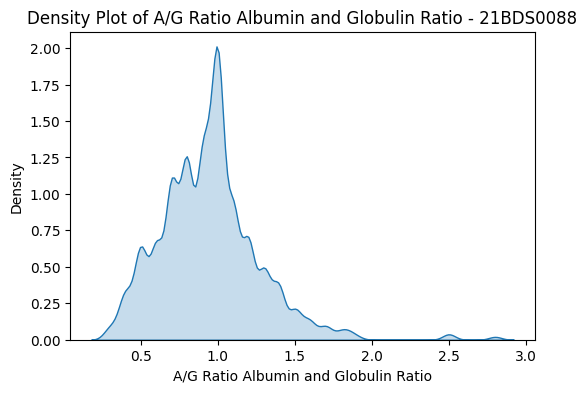

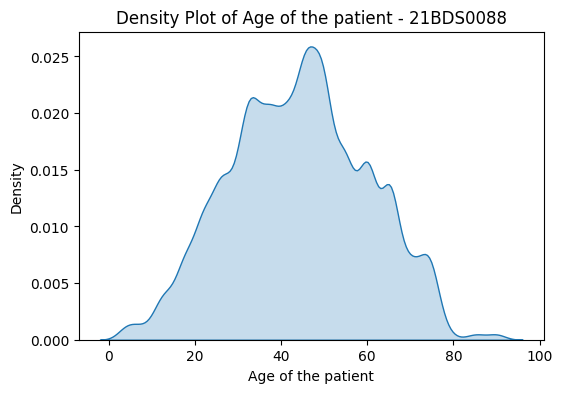

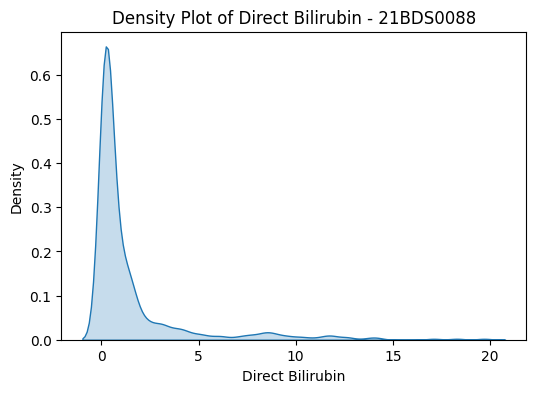

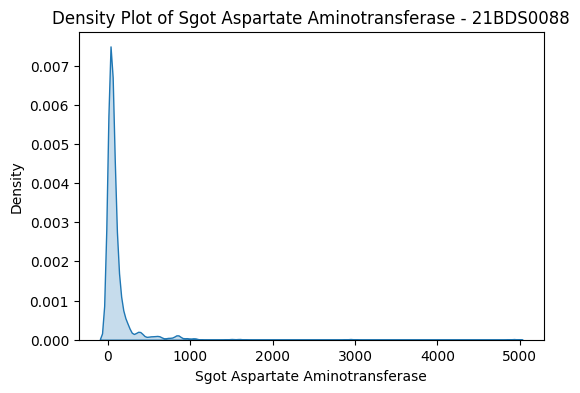

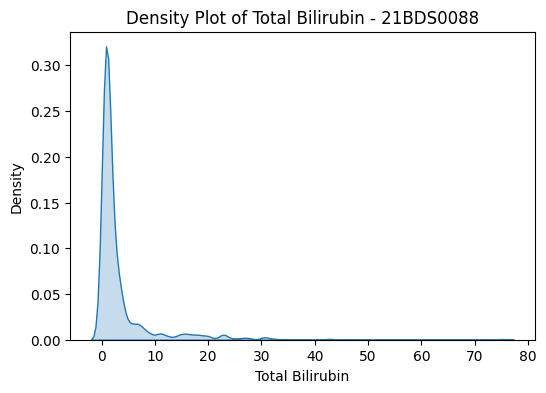

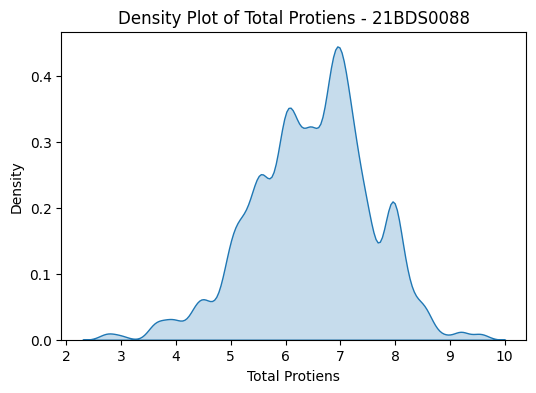

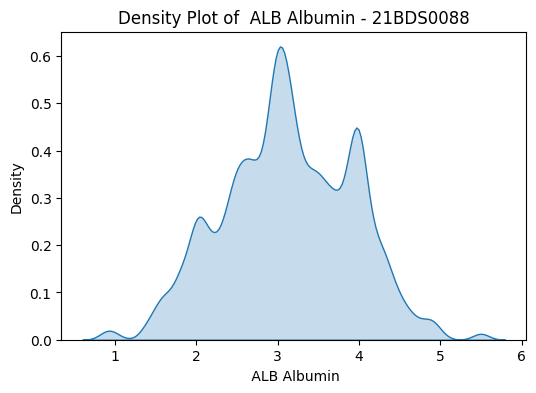

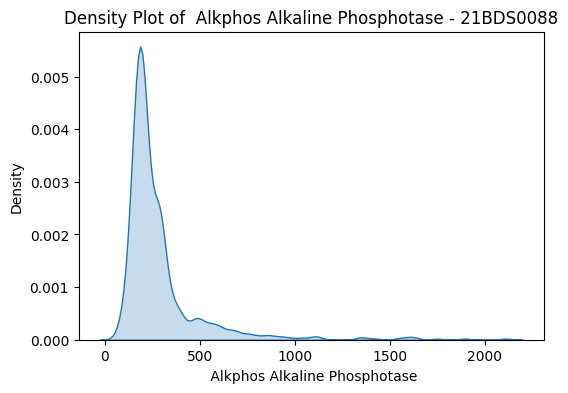

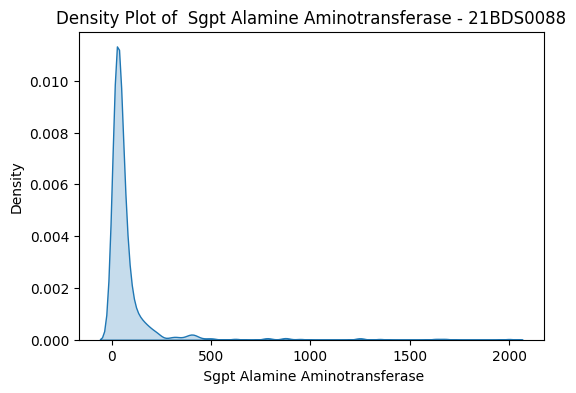

In [14]:
#Plot density plots for all numerical columns.
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(ac_data[col], fill=True)
    plt.title(f"Density Plot of {col} - 21BDS0088")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()
    print("\n")


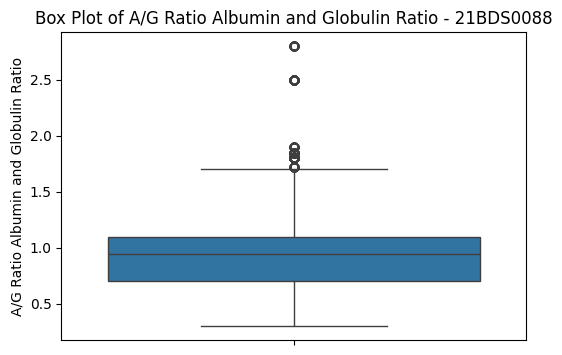

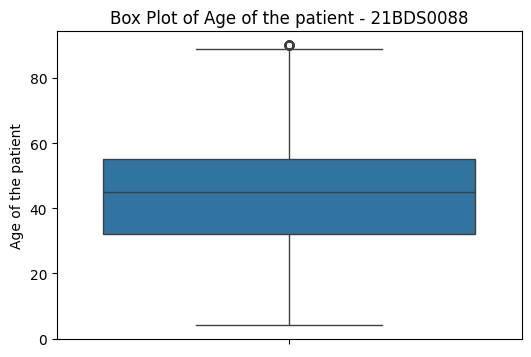

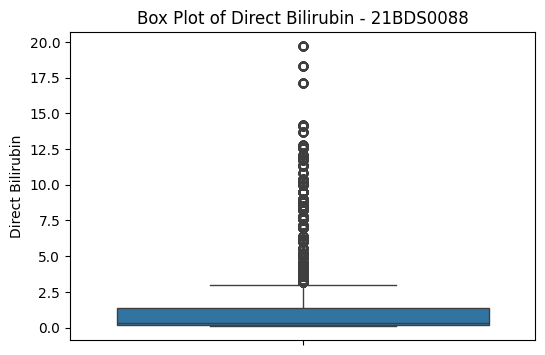

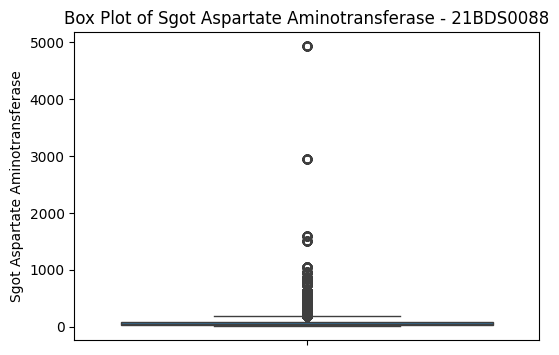

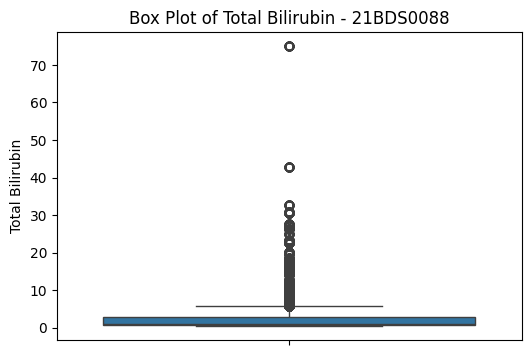

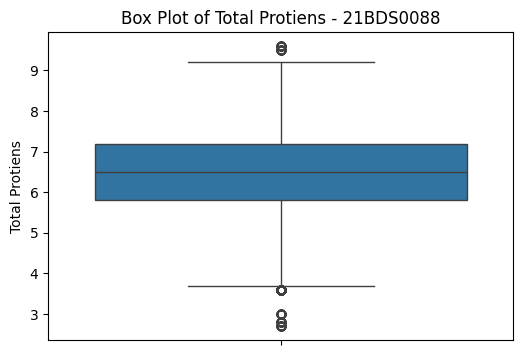

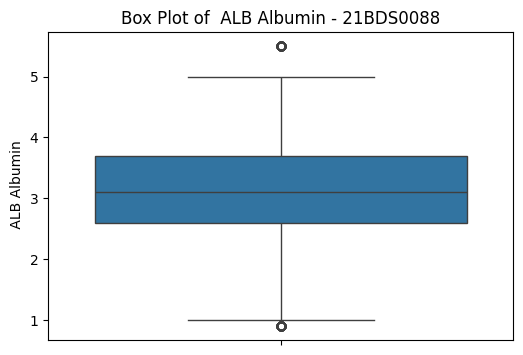

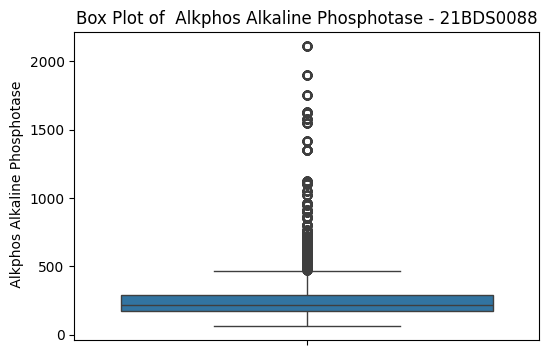

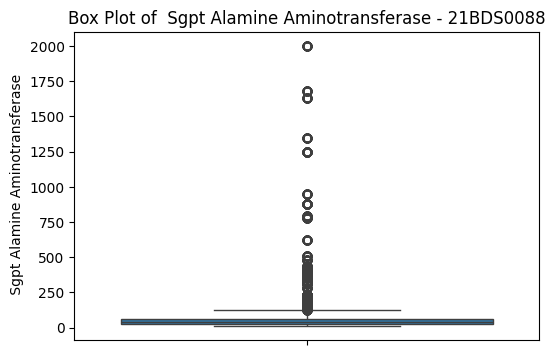

In [15]:
#Plot box plots for all numerical columns.
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=ac_data[col])
    plt.title(f"Box Plot of {col} - 21BDS0088")
    plt.show()
    print("\n")


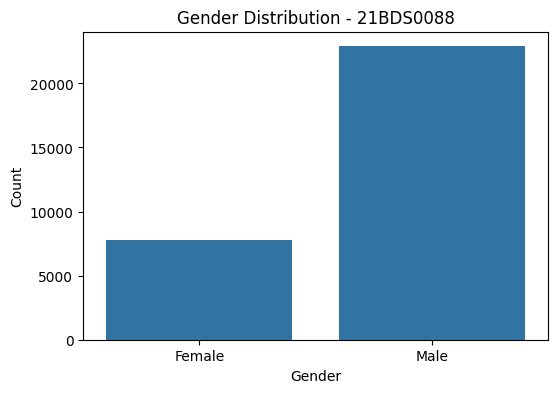

In [16]:
#Display a bar plot for Gender of the patient.
plt.figure(figsize=(6,4))
sns.countplot(x='Gender of the patient', data=ac_data)
plt.title("Gender Distribution - 21BDS0088")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

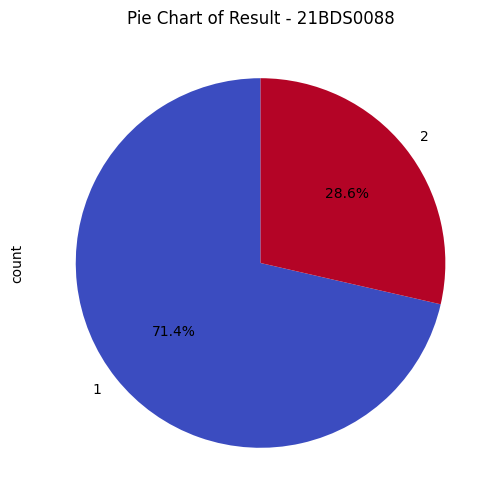

In [17]:
#Display a pie chart for Result.
ac_data['Result'].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, cmap="coolwarm", figsize=(6,6))
plt.title("Pie Chart of Result - 21BDS0088")
plt.show()

# **Bivariate Analysis**

In [18]:
#Create a contingency table for Gender of the patient vs Result.
contingency_table = pd.crosstab(ac_data['Gender of the patient'], ac_data['Result'])
print("\nContingency Table:\n", contingency_table)


Contingency Table:
 Result                     1     2
Gender of the patient             
Female                  5553  2250
Male                   16364  6524


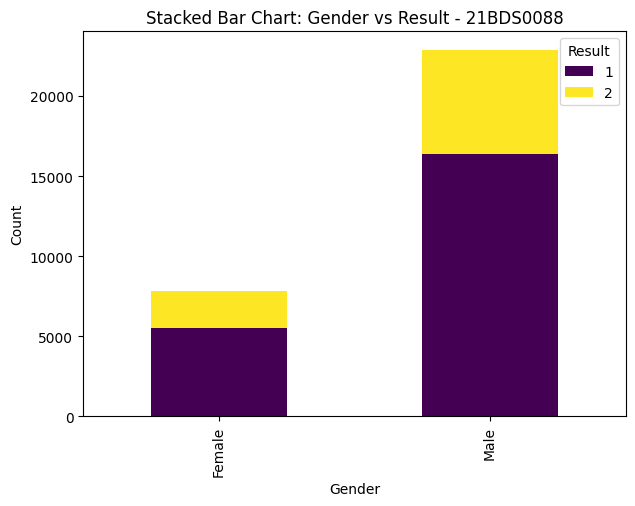

In [19]:
#Display a stacked bar chart for Gender of the patient vs Result.
contingency_table.plot(kind="bar", stacked=True, figsize=(7,5), colormap="viridis")
plt.title("Stacked Bar Chart: Gender vs Result - 21BDS0088")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Result")
plt.show()

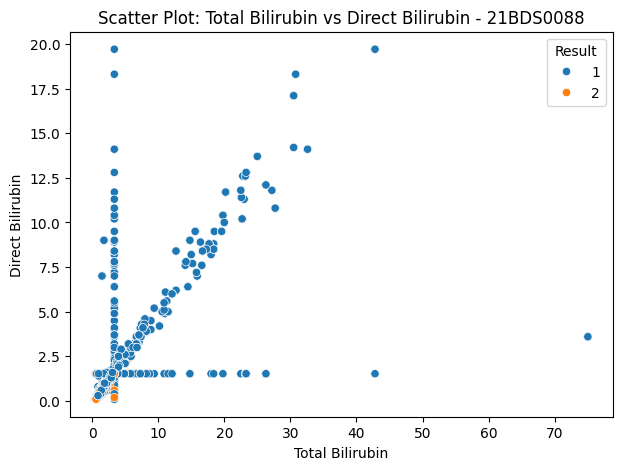

In [20]:
#Display a scatter plot for Total Bilirubin vs Direct Bilirubin.
plt.figure(figsize=(7,5))
sns.scatterplot(x='Total Bilirubin', y='Direct Bilirubin', hue='Result', data=ac_data)
plt.title("Scatter Plot: Total Bilirubin vs Direct Bilirubin - 21BDS0088")
plt.xlabel("Total Bilirubin")
plt.ylabel("Direct Bilirubin")
plt.show()


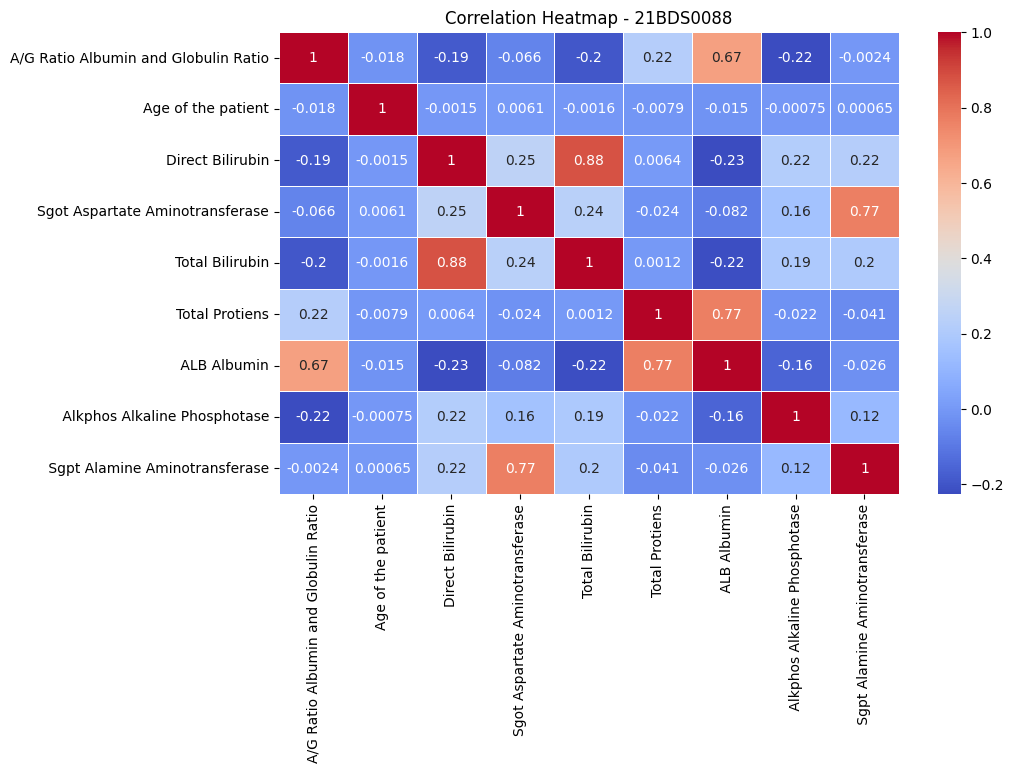

In [21]:
#Display a heatmap of correlations for all numerical variables.
plt.figure(figsize=(10,6))
sns.heatmap(ac_data[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - 21BDS0088")
plt.show()

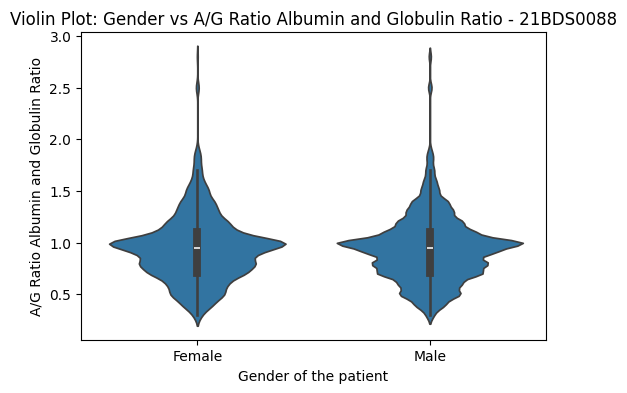

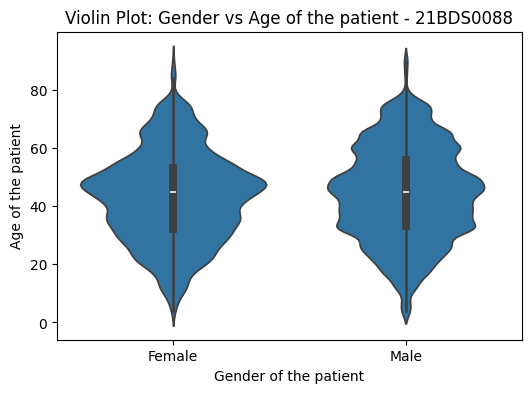

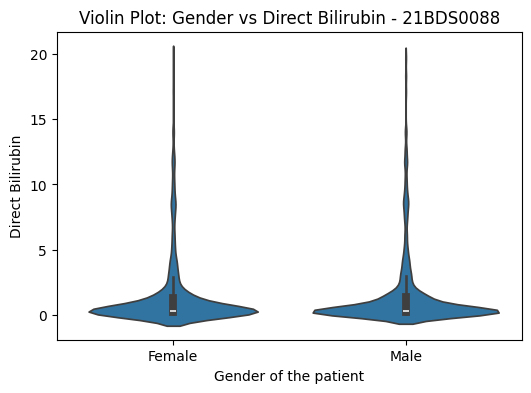

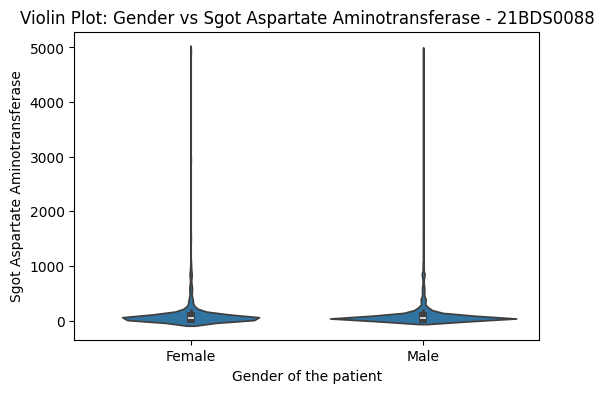

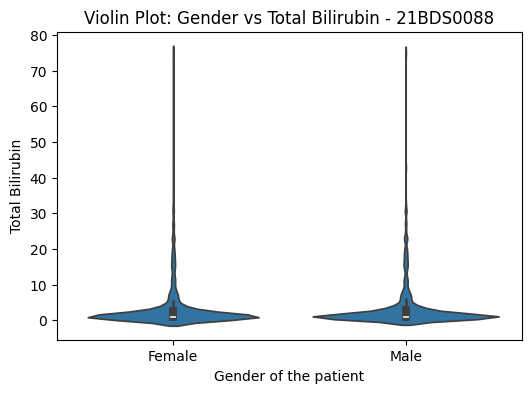

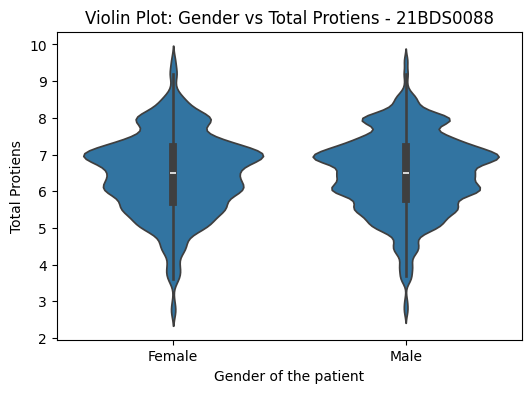

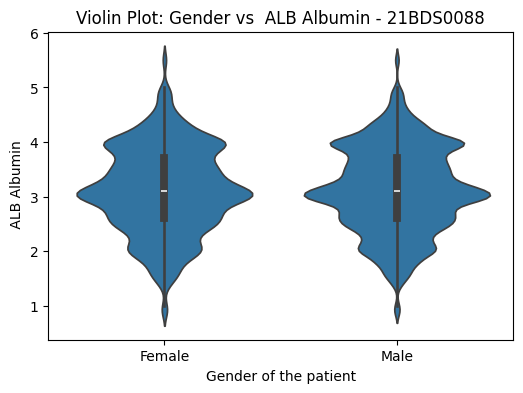

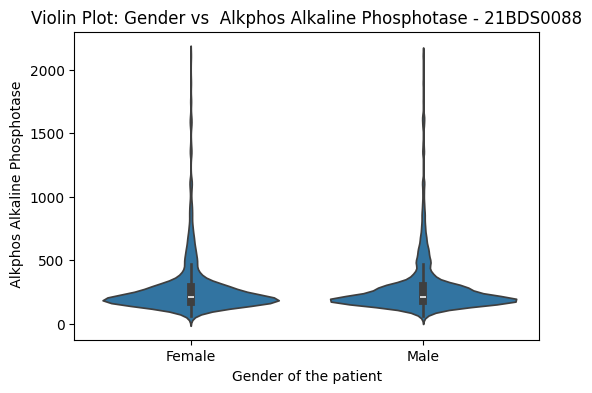

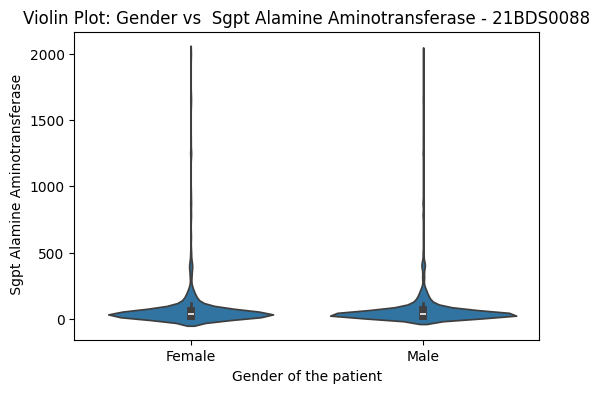

In [22]:
# Violin Plot comparing Gender with all numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(x='Gender of the patient', y=col, data=ac_data)
    plt.title(f"Violin Plot: Gender vs {col} - 21BDS0088")
    plt.show()
    print("\n")

# **Multivariate Analysis**

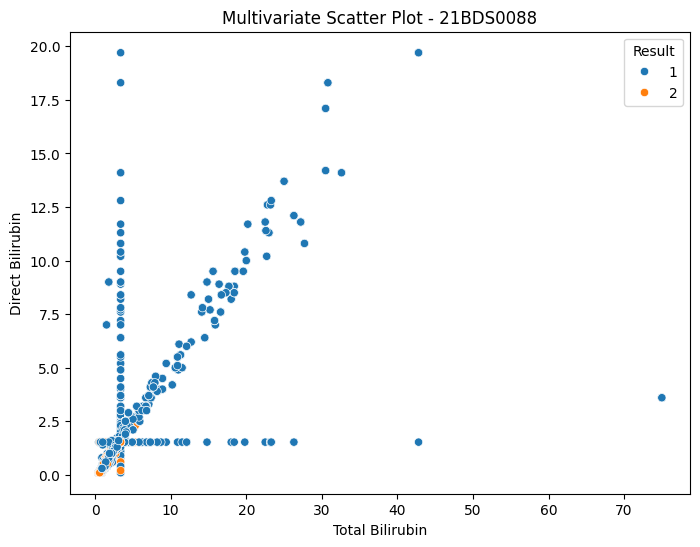

In [23]:
#Display a scatter plot using Total Bilirubin vs Direct Bilirubin, colored by Result.
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Bilirubin', y='Direct Bilirubin', hue='Result', data=ac_data)
plt.title("Multivariate Scatter Plot - 21BDS0088")
plt.xlabel("Total Bilirubin")
plt.ylabel("Direct Bilirubin")
plt.show()

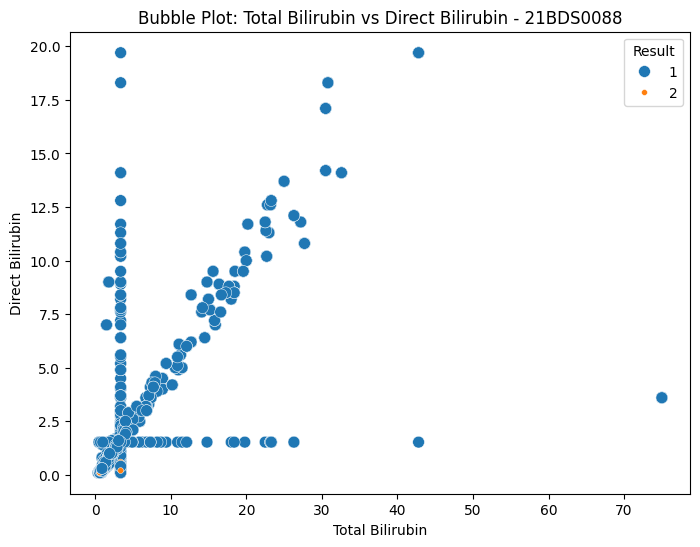

In [24]:
#Display a bubble plot using Total Bilirubin, Direct Bilirubin, and Result as size.
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Bilirubin', y='Direct Bilirubin', hue='Result', size='Result', data=ac_data)
plt.title("Bubble Plot: Total Bilirubin vs Direct Bilirubin - 21BDS0088")
plt.xlabel("Total Bilirubin")
plt.ylabel("Direct Bilirubin")
plt.show()

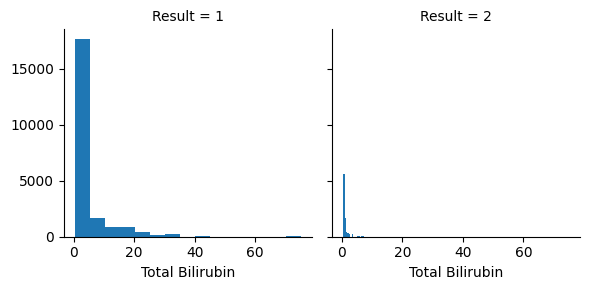

In [25]:
#Display multiple histograms using FacetGrid for Result classification.
g = sns.FacetGrid(ac_data, col="Result")
g.map(plt.hist, "Total Bilirubin", bins=15)
plt.show()


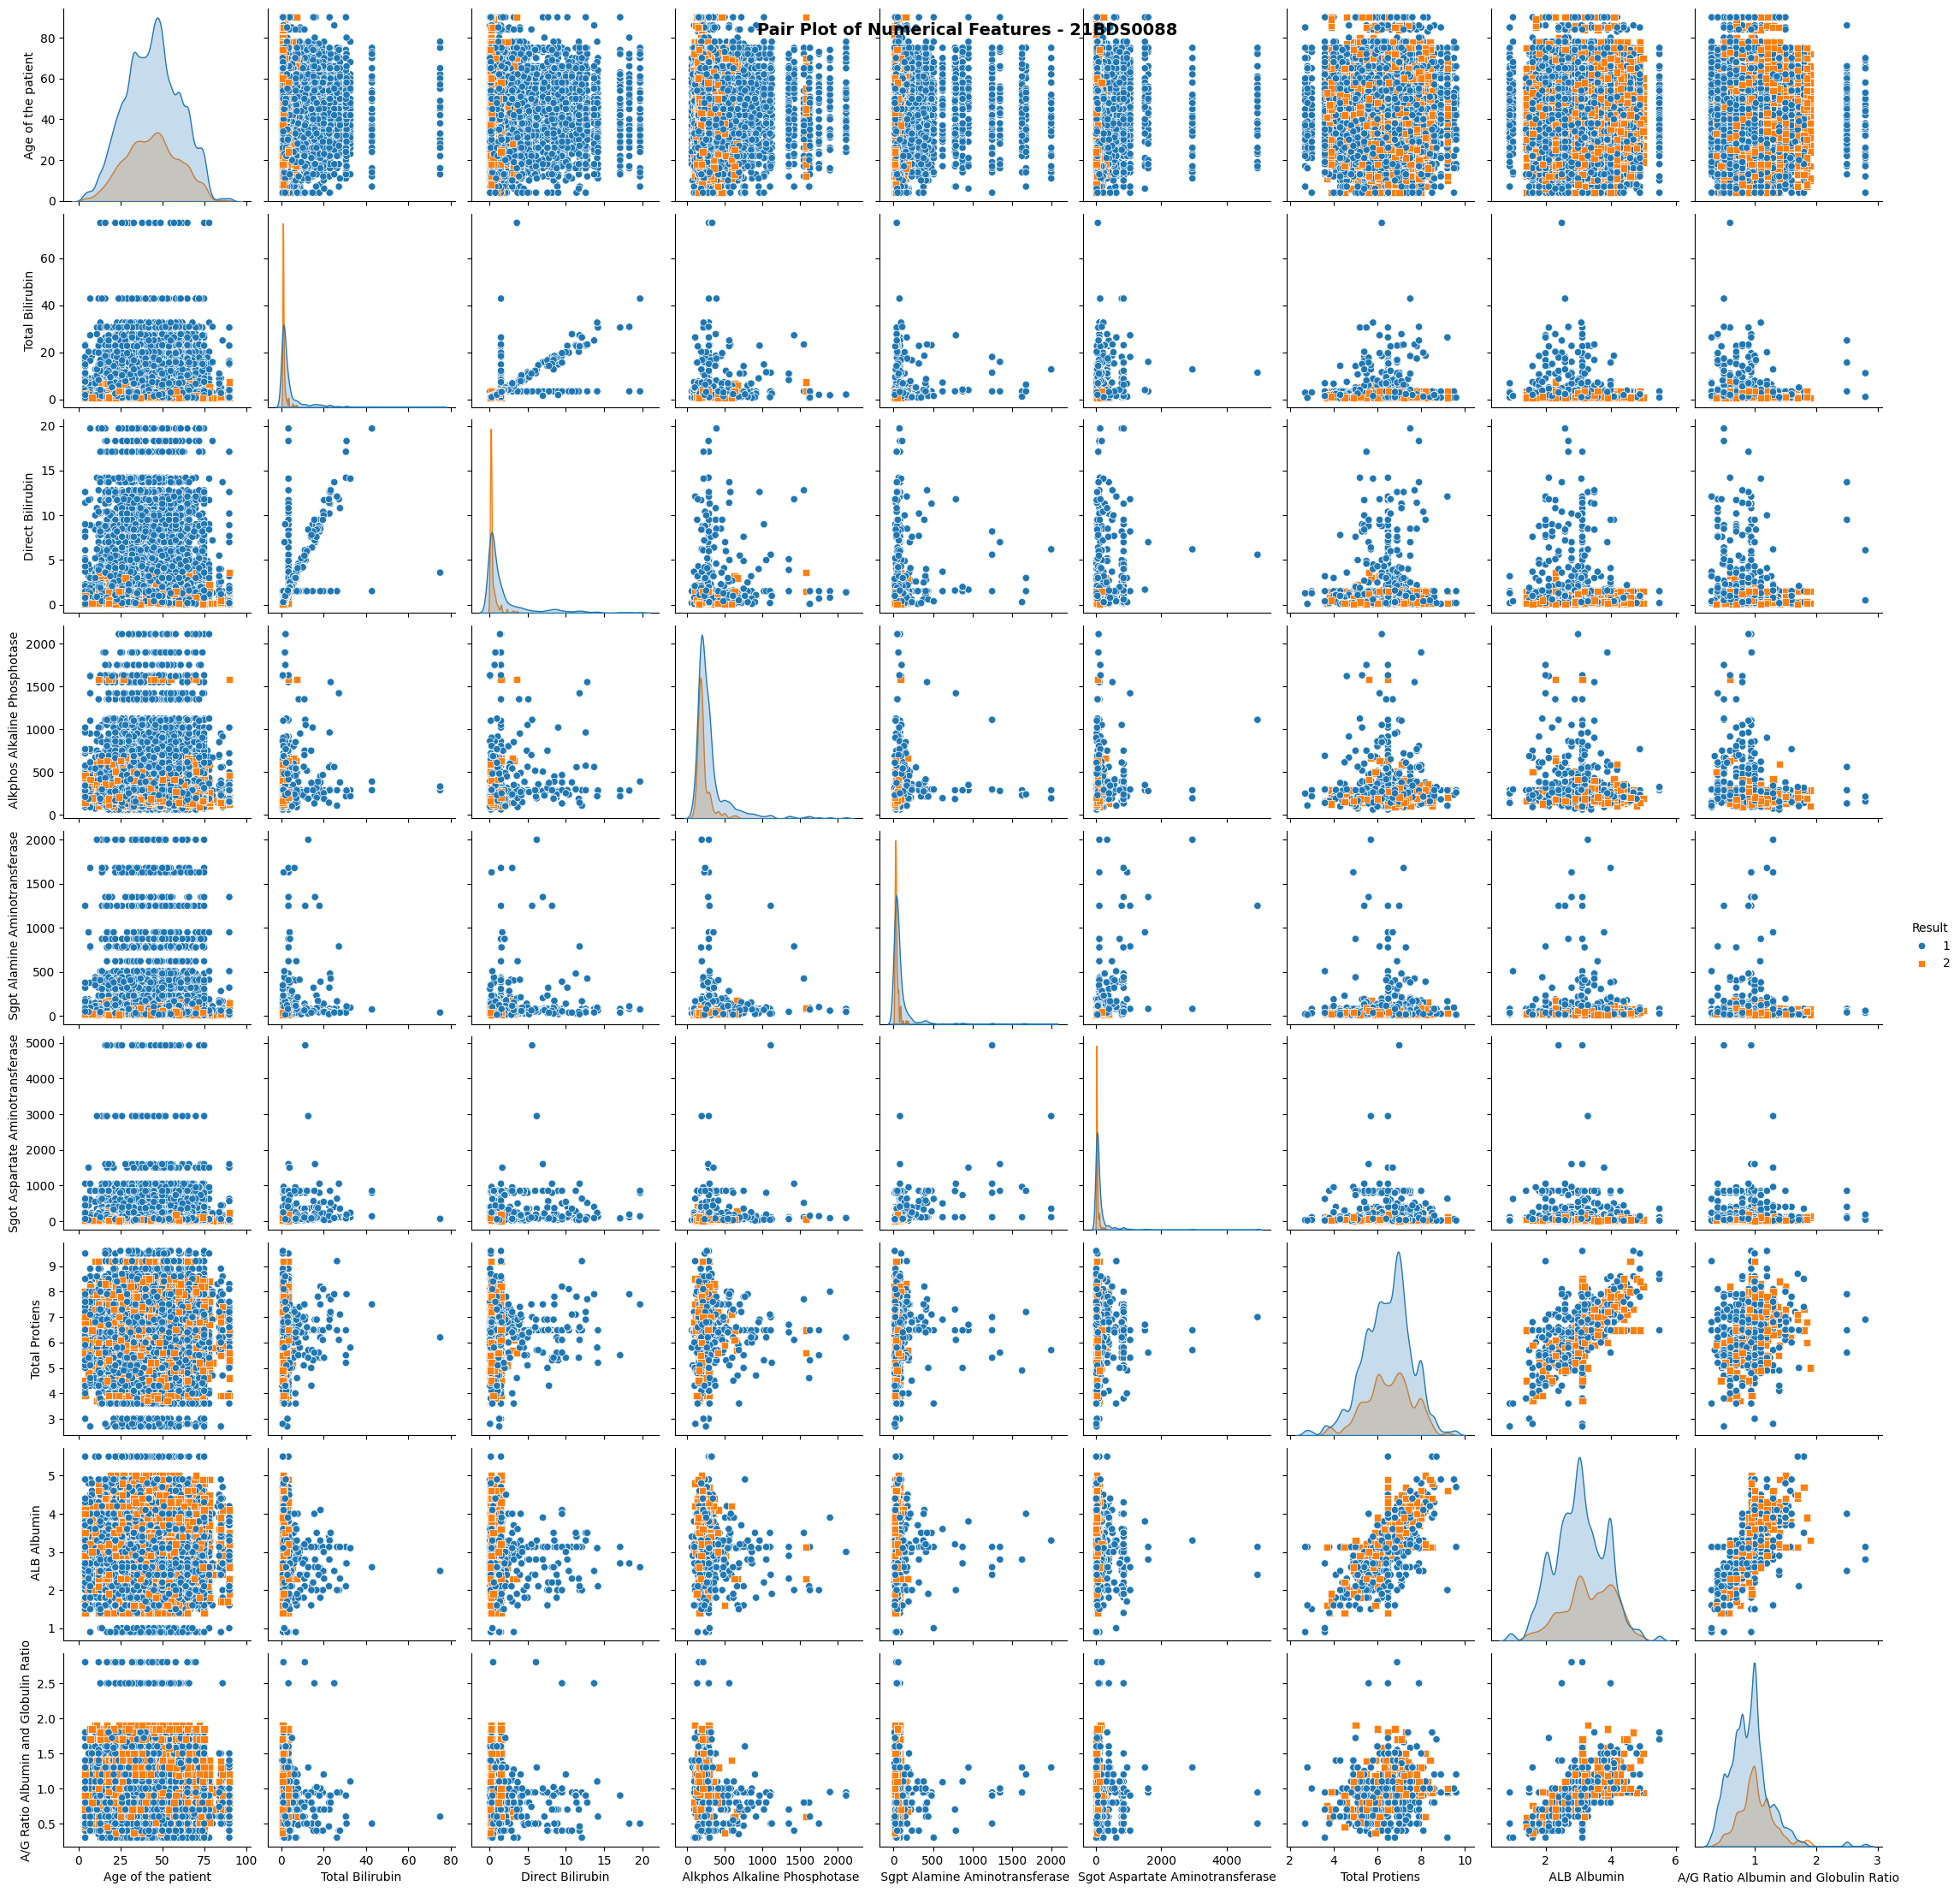

In [26]:
#Display a pair plot to visualize pairwise relationships between numerical columns.
sns.pairplot(ac_data, hue="Result", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pair Plot of Numerical Features - 21BDS0088 \n", fontsize=14, fontweight='bold')
plt.show()

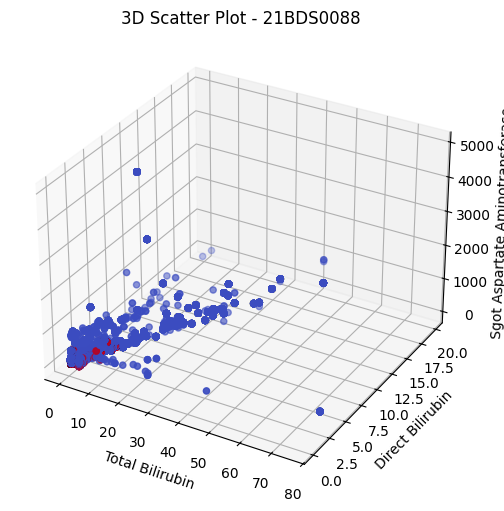

In [27]:
#Generate a 3D scatter plot for Total Bilirubin, Direct Bilirubin, and Sgot Aspartate Aminotransferase
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(ac_data['Total Bilirubin'], ac_data['Direct Bilirubin'], ac_data['Sgot Aspartate Aminotransferase'], c=ac_data['Result'], cmap='coolwarm')

ax.set_xlabel('Total Bilirubin')
ax.set_ylabel('Direct Bilirubin')
ax.set_zlabel('Sgot Aspartate Aminotransferase')
ax.set_title("3D Scatter Plot - 21BDS0088")

plt.show()

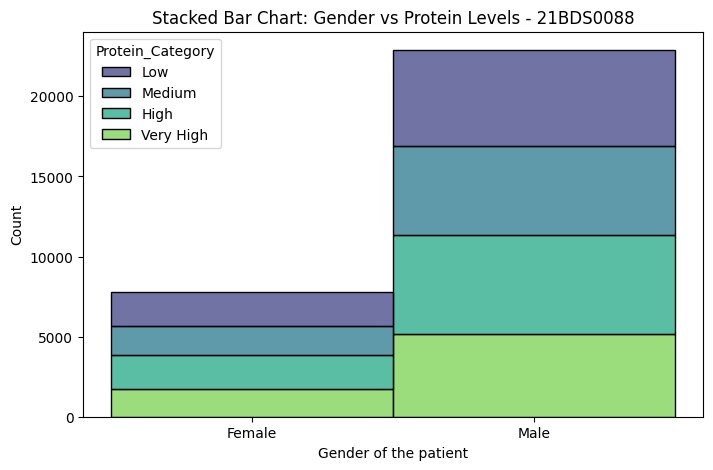

In [28]:
#Generate a stacked bar plot for Gender of the patient vs Result, with different colors for Total Protiens ranges.
ac_data['Protein_Category'] = pd.qcut(ac_data['Total Protiens'], q=4, labels=["Low", "Medium", "High", "Very High"])

plt.figure(figsize=(8,5))
sns.histplot(data=ac_data, x='Gender of the patient', hue='Protein_Category', multiple="stack", palette="viridis")
plt.title("Stacked Bar Chart: Gender vs Protein Levels - 21BDS0088")
plt.show()

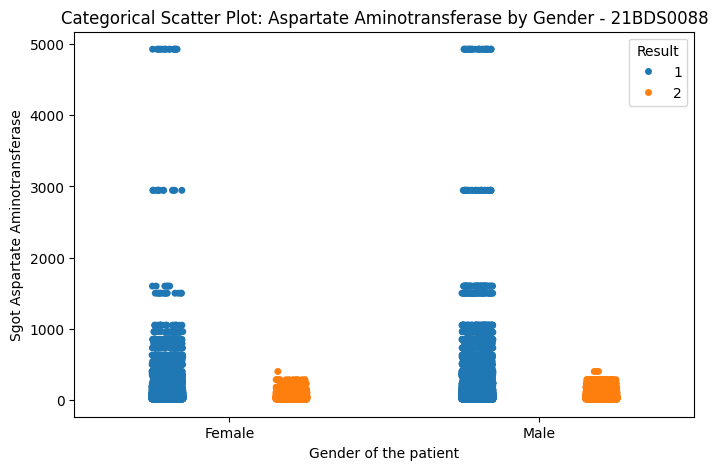

In [29]:
#Create a categorical scatter plot (stripplot) for Sgot Aspartate Aminotransferase, grouped by Gender of the patient, with Result as hue.
plt.figure(figsize=(8,5))
sns.stripplot(x='Gender of the patient', y='Sgot Aspartate Aminotransferase', hue="Result", data=ac_data, jitter=True, dodge=True)
plt.title("Categorical Scatter Plot: Aspartate Aminotransferase by Gender - 21BDS0088")
plt.show()

# **Clustering Algorithms**

In [31]:
num_cols = ac_data.select_dtypes(include=np.number).columns

In [46]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [33]:
# Scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ac_data[num_cols])

# **Hierarchical Clustering**

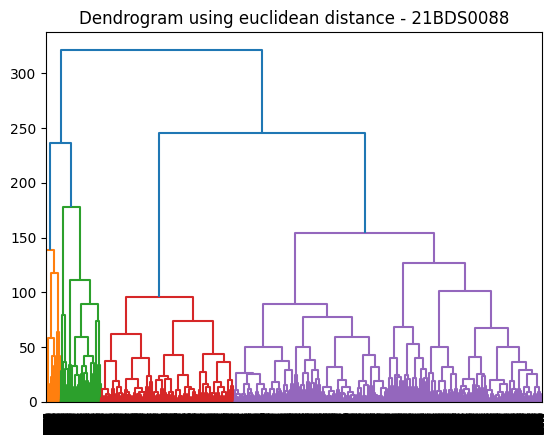

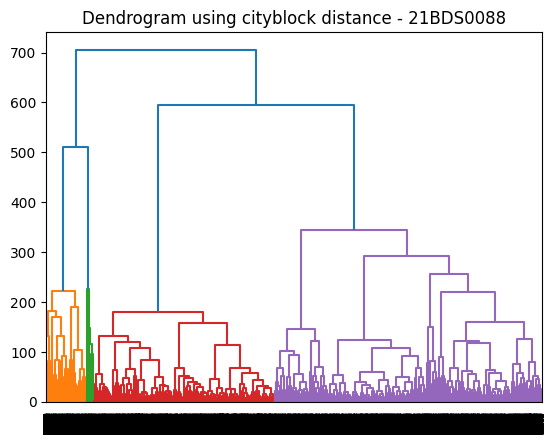

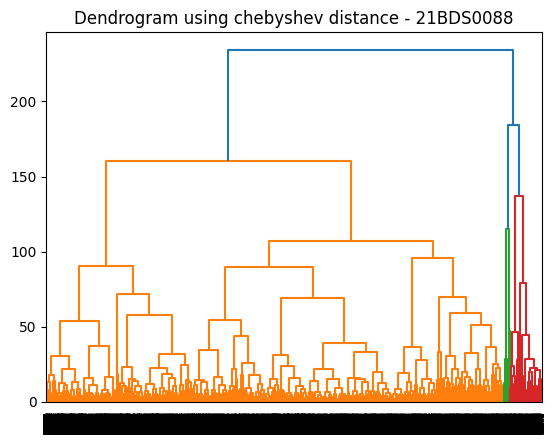

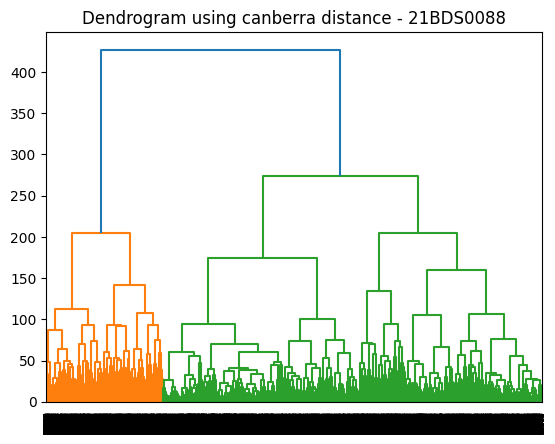

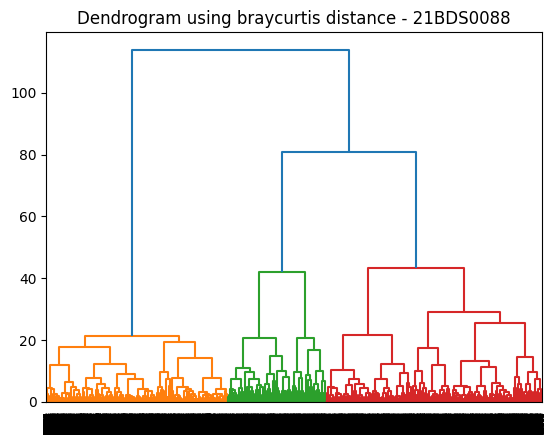

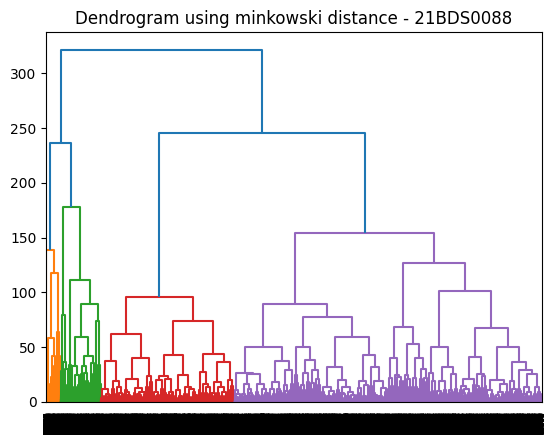

In [37]:
# Distance Metrics + Dendrograms
distance_metrics = ['euclidean', 'cityblock', 'chebyshev', 'canberra', 'braycurtis', 'minkowski']
for metric in distance_metrics:
    dist_matrix = pdist(scaled_data, metric=metric)
    link_matrix = linkage(dist_matrix, method='ward')
    plt.figure()
    dendrogram(link_matrix)
    plt.title(f'Dendrogram using {metric} distance - 21BDS0088')
    plt.show()

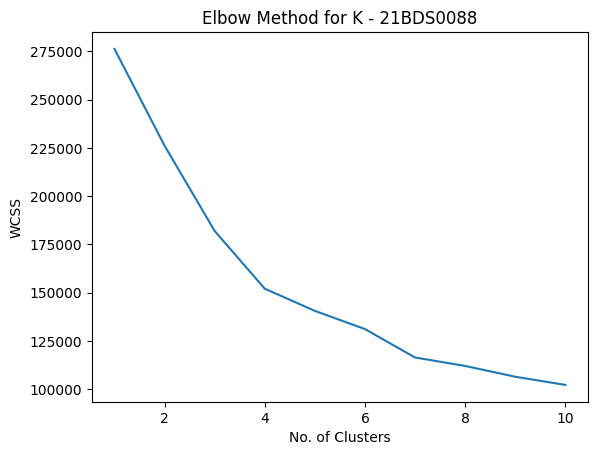

In [38]:
# KMeans Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method for K - 21BDS0088")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [47]:
# Final KMeans
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(scaled_data)

Text(0.5, 1.0, 'KMeans Clustering Visualization - 21BDS0088')

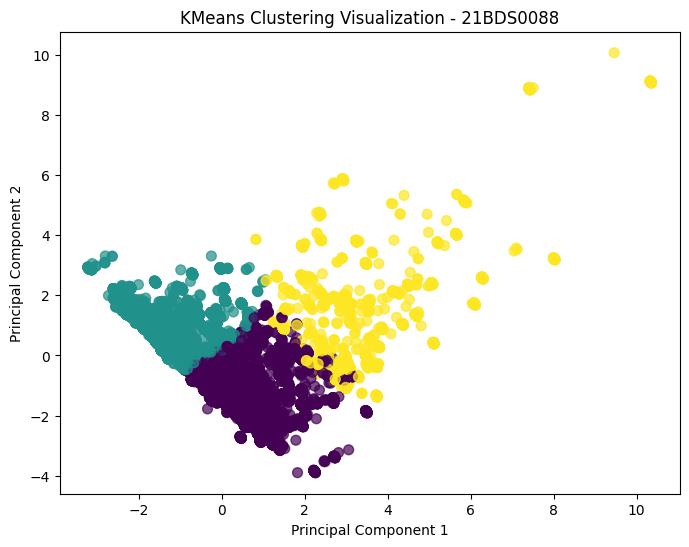

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KMeans Clustering Visualization - 21BDS0088')

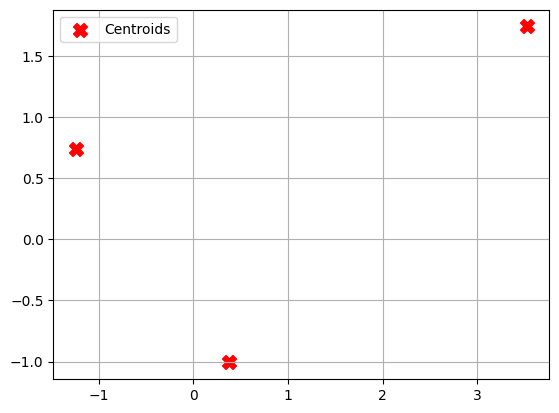

In [50]:
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100, label='Centroids')
plt.legend()
plt.grid(True)
plt.show()

# **DBSCAN**

In [51]:
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(scaled_data)

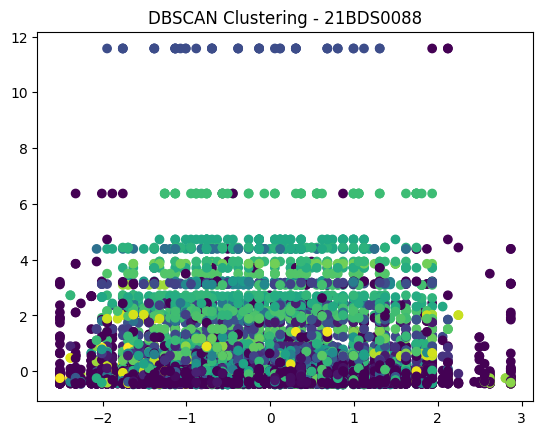

In [52]:
# DBSCAN Visualization
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=db_labels, cmap='viridis')
plt.title("DBSCAN Clustering - 21BDS0088")
plt.show()

# **Dimensionality Reduction**

In [53]:
from sklearn.decomposition import PCA

# PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

In [54]:
eigenvalues = pca.explained_variance_
print("Eigenvalues:\n", eigenvalues)

Eigenvalues:
 [2.67498659 1.91367122 1.36813897 0.9998384  0.94192954 0.6807835
 0.22729845 0.12306097 0.0705856 ]


In [55]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=num_cols
)
print("Component Loadings:\n", loadings)

Component Loadings:
                                            PC1       PC2       PC3       PC4  \
Age of the patient                    0.008999 -0.017182  0.021412  0.998689   
Total Bilirubin                       0.438199  0.223566 -0.450070  0.001099   
Direct Bilirubin                      0.443872  0.232069 -0.439068  0.001168   
 Alkphos Alkaline Phosphotase         0.249654  0.037717 -0.078773  0.008920   
 Sgpt Alamine Aminotransferase        0.292631  0.392764  0.514243 -0.009270   
Sgot Aspartate Aminotransferase       0.325687  0.377740  0.483583 -0.000219   
Total Protiens                       -0.250136  0.476765 -0.293542  0.041154   
 ALB Albumin                         -0.416010  0.497112 -0.108216  0.016429   
A/G Ratio Albumin and Globulin Ratio -0.348157  0.350810  0.042628 -0.022113   

                                           PC5       PC6       PC7       PC8  \
Age of the patient                   -0.027407  0.031947 -0.003770  0.000126   
Total Bilirubin   

In [56]:
# Explained Variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.29721105 0.21262321 0.15201049 0.11108954 0.10465543 0.07564015
 0.02525456 0.013673   0.00784259]


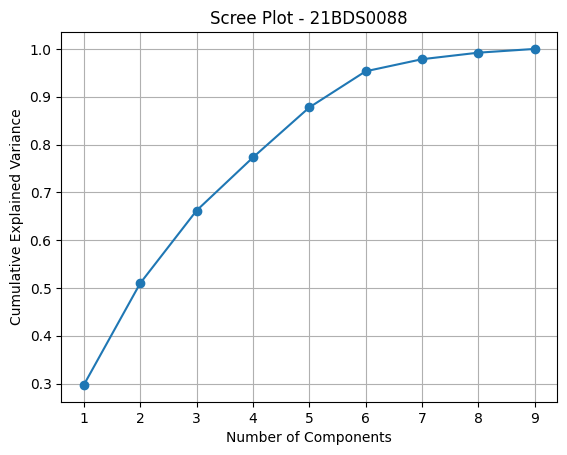

In [57]:
# Scree Plot
plt.figure()
plt.plot(range(1, len(eigenvalues) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Scree Plot - 21BDS0088")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

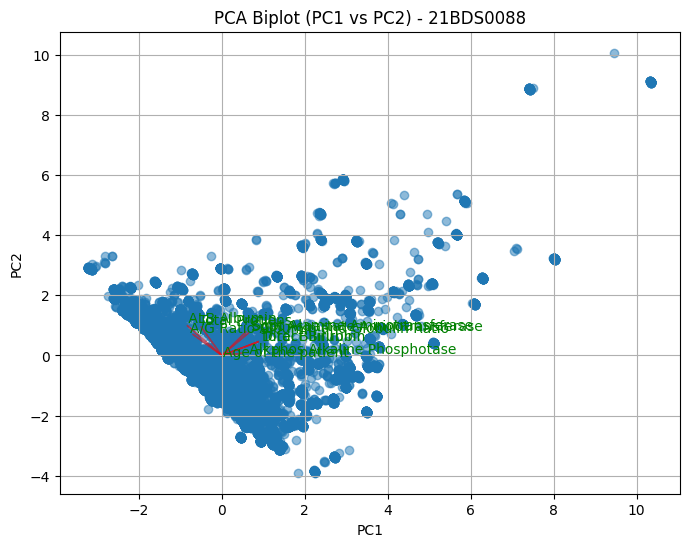

In [58]:
# Biplot
def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    plt.figure(figsize=(8, 6))
    plt.scatter(xs, ys, alpha=0.5)
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i, 0]*2, coeff[i, 1]*2,
                  color='r', alpha=0.5)
        if labels is None:
            plt.text(coeff[i, 0]*2.2, coeff[i, 1]*2.2, f"Var{i+1}", color='g')
        else:
            plt.text(coeff[i, 0]*2.2, coeff[i, 1]*2.2, labels[i], color='g')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Biplot (PC1 vs PC2) - 21BDS0088")
    plt.grid()
    plt.show()

biplot(pca_data, np.array(pca.components_).T, labels=num_cols)

In [59]:
# Select number of components (e.g., 2) and reapply PCA
pca_n = PCA(n_components=2)
pca_data_n = pca_n.fit_transform(scaled_data)

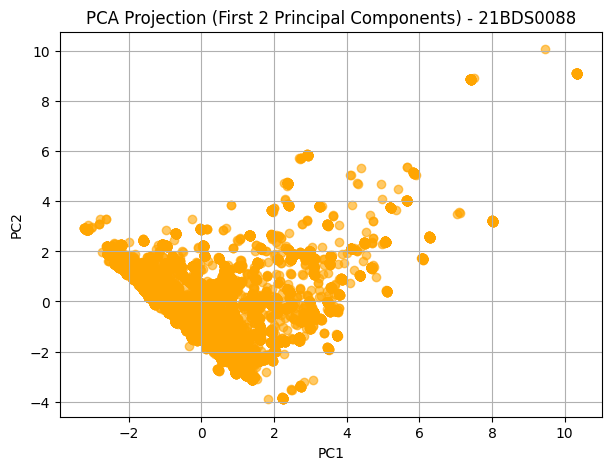

In [60]:
# 2D PCA Plot
plt.figure(figsize=(7, 5))
plt.scatter(pca_data_n[:, 0], pca_data_n[:, 1], alpha=0.6, c='orange')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (First 2 Principal Components) - 21BDS0088')
plt.grid(True)
plt.show()

In [61]:
# Summary-like Interpretation
print("Selected Components' Explained Variance Ratio:", pca_n.explained_variance_ratio_)
print("Selected Components' Loadings:\n", pd.DataFrame(
    pca_n.components_.T, columns=['PC1', 'PC2'], index=num_cols))

Selected Components' Explained Variance Ratio: [0.29721105 0.21262321]
Selected Components' Loadings:
                                            PC1       PC2
Age of the patient                    0.008999 -0.017182
Total Bilirubin                       0.438199  0.223566
Direct Bilirubin                      0.443872  0.232069
 Alkphos Alkaline Phosphotase         0.249654  0.037717
 Sgpt Alamine Aminotransferase        0.292631  0.392764
Sgot Aspartate Aminotransferase       0.325687  0.377740
Total Protiens                       -0.250136  0.476765
 ALB Albumin                         -0.416010  0.497112
A/G Ratio Albumin and Globulin Ratio -0.348157  0.350810


# **Model Development and Evaluation**

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import scipy.stats as stats

# **Simple Linear Regression**

In [67]:
X = ac_data[['Total Bilirubin']]
y = ac_data['\xa0ALB Albumin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [68]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [69]:
# Evaluation
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.044634743062009985
MAE: 0.6221663637357284
MSE: 0.5946005679503202
RMSE: 0.771103474217514


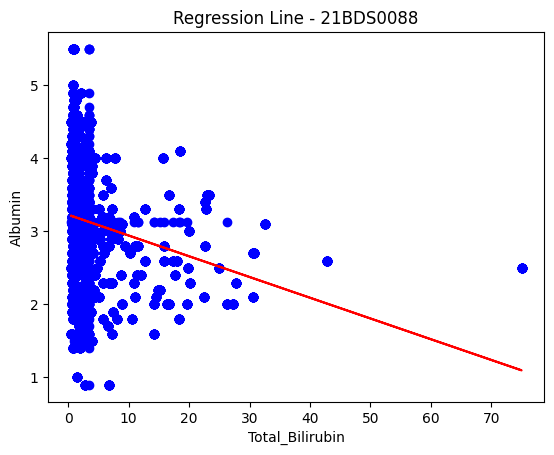

In [70]:
# Regression Plot
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.title("Regression Line - 21BDS0088")
plt.xlabel("Total_Bilirubin")
plt.ylabel("Albumin")
plt.show()

# **Multiple Linear Regression with Log Transformation**

In [71]:
print(ac_data.columns.tolist())

['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result', 'Protein_Category']


In [72]:
# Select predictors and target
predictors = ['Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'A/G Ratio Albumin and Globulin Ratio']
target = '\xa0ALB Albumin'

In [73]:
X = ac_data[predictors]
y = ac_data[target]

In [74]:
# Log transform the target
y_log = np.log1p(y)

In [75]:
# Train-Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.33, random_state=42)

In [76]:
# Fit the model
model = LinearRegression()
model.fit(X_train, y_train_log)

LinearRegression()

In [77]:
# Predictions
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test_log)

In [78]:
# Evaluation
print("R² Score:", r2_score(y_actual, y_pred))
print("MAE:", mean_absolute_error(y_actual, y_pred))
print("MSE:", mean_squared_error(y_actual, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_actual, y_pred)))

R² Score: 0.8546658135189199
MAE: 0.1581230673136221
MSE: 0.09045314260350684
RMSE: 0.30075428941830046


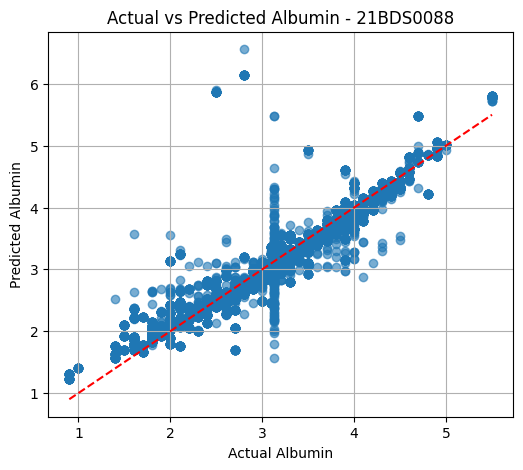

In [79]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_actual, y_pred, alpha=0.6)
plt.xlabel("Actual Albumin")
plt.ylabel("Predicted Albumin")
plt.title("Actual vs Predicted Albumin - 21BDS0088")
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')  # diagonal line
plt.grid(True)
plt.show()

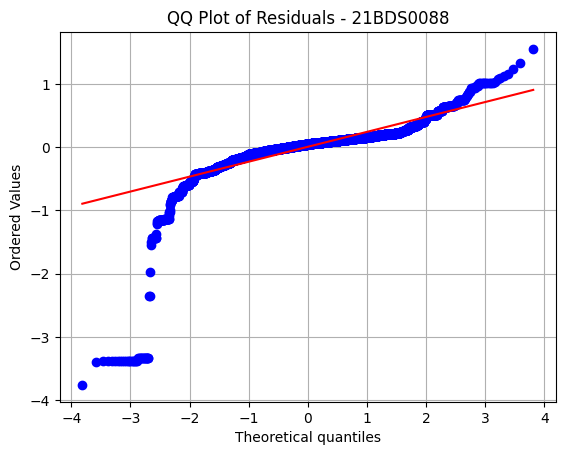

In [80]:
# QQ Plot of residuals
residuals = y_actual - y_pred
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals - 21BDS0088")
plt.grid(True)
plt.show()